## Baseline Model
Applied algorithm: Multinomial Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

df = pd.read_csv("cleaned_data.csv")
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# Define a threshold for classifying the four moods based on valence and energy
def assign_mood(row):
    if row['valence'] >= 0.5 and row['energy'] >= 0.5:
        return 'Happy'
    elif row['valence'] < 0.5 and row['energy'] >= 0.5:
        return 'Angry'
    elif row['valence'] >= 0.5 and row['energy'] < 0.5:
        return 'Calm'
    else:
        return 'Sad'

# Remove "valence" and "energy" from the list of features to avoid data leakage

df['mood'] = df.apply(assign_mood, axis=1)
features = ['popularity', 'duration_ms', 'explicit', 'danceability', 
            'key', 'loudness', 'mode', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'tempo', 'time_signature']
numerical_cols = ['popularity', 'duration_ms', 'explicit', 'danceability',
                      'loudness', 'speechiness', 'acousticness', 
                      'instrumentalness', 'liveness', 'tempo']
categorical_cols = ['key', 'mode', 'time_signature']
X = df[features]
y = df["mood"]

Spliting into train/dev/test with proportion 80/10/10

In [3]:
# Split train/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# Split train/dev
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test: {len(X_test)}")

Train: 65081 | Dev: 8127 | Test: 8135


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

log_reg = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(solver='lbfgs', max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [5]:
y_pred = log_reg.predict(X_dev)
print(y_pred[:5])
y_prob = log_reg.predict_proba(X_dev)
res = pd.DataFrame({"true_mood": y_dev.values, "predicted_mood": y_pred, "predicted_probability": y_prob.max(axis=1)})
res.head(5)

['Happy' 'Happy' 'Angry' 'Calm' 'Angry']


,true_mood,predicted_mood,predicted_probability
0,Happy,Happy,0.603817
1,Sad,Happy,0.387426
2,Sad,Angry,0.647852
3,Calm,Calm,0.532342
4,Angry,Angry,0.968897


Note: The sum of predicted probability for each of the 4 class in each song = 1

In [6]:
accuracy = accuracy_score(y_dev, y_pred)
precision = precision_score(y_dev, y_pred, average="macro")
recall = recall_score(y_dev, y_pred, average="macro")
f1 = f1_score(y_dev, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6406
Precision: 0.6186
Recall   : 0.5732
F1 Score : 0.5815


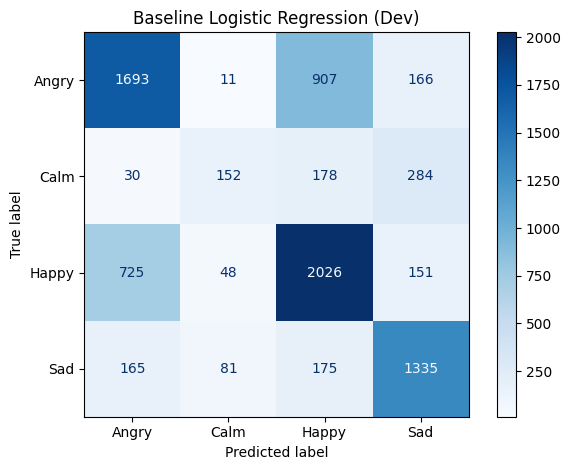

In [7]:
cm = confusion_matrix(y_dev, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_
)

disp.plot(cmap='Blues')
plt.title("Baseline Logistic Regression (Dev)")
plt.tight_layout()
plt.show()

Problems:
1. Angry - happy mistakes is large (with 907 angry predicted as happy and 725 happy predicted as angry)
2. Recall on calm is too low

In [8]:
print("Train: ", accuracy_score(y_train, log_reg.predict(X_train)))
print("Dev: ", accuracy_score(y_dev, log_reg.predict(X_dev)))

Train:  0.6461486455340268
Dev:  0.6405807801156639


Problem: Underfitting

Solution: Since valence and energy where the 2 features that we based on to separate the moods, but they were removed,
we can add a new feature that is more informative about mood

## Improved Model
1. Add a new feature about rythm intensity, which could suggest more about the song's arousal (more joy/aggressive or
calm/sadness).
2. Use decision tree to create non-linear decision boundaries to better separate the 4 moods.

In [9]:
# Normalize tempo to 0-1 range
df['tempo_norm'] = (df['tempo'] - df['tempo'].min()) / (df['tempo'].max() - df['tempo'].min())

# Normalize loudness to 0-1 range
df['loudness_norm'] = (df['loudness'] - df['loudness'].min()) / (df['loudness'].max() - df['loudness'].min())

# Engineered feature
df['rhythm_intensity'] = (
    df['danceability'] * df['tempo_norm'] * (1 - df['acousticness'])
)
features = ['popularity', 'duration_ms', 'explicit', 'danceability', 
            'key', 'loudness', 'mode', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'tempo', 'time_signature', 'rhythm_intensity']

numerical_cols = ['popularity', 'duration_ms', 'explicit', 'danceability',
                      'loudness', 'speechiness', 'acousticness', 
                      'instrumentalness', 'liveness', 'tempo', 'rhythm_intensity']

categorical_cols = ['key', 'mode', 'time_signature']

X = df[features]
y = df["mood"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

log_reg = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(solver='lbfgs', max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
y_pred = log_reg.predict(X_dev)
print(y_pred[:5])
y_prob = log_reg.predict_proba(X_dev)
res = pd.DataFrame({"true_mood": y_dev.values, "predicted_mood": y_pred, "predicted_probability": y_prob.max(axis=1)})
res.head(5)

['Happy' 'Happy' 'Angry' 'Calm' 'Angry']


,true_mood,predicted_mood,predicted_probability
0,Happy,Happy,0.594724
1,Sad,Happy,0.382112
2,Sad,Angry,0.630160
3,Calm,Calm,0.539834
4,Angry,Angry,0.959151


In [12]:
accuracy = accuracy_score(y_dev, y_pred)
precision = precision_score(y_dev, y_pred, average="macro")
recall = recall_score(y_dev, y_pred, average="macro")
f1 = f1_score(y_dev, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6414
Precision: 0.6216
Recall   : 0.5744
F1 Score : 0.5831


In [13]:
print("Train: ", accuracy_score(y_train, log_reg.predict(X_train)))
print("Dev: ", accuracy_score(y_dev, log_reg.predict(X_dev)))

Train:  0.6461332800663788
Dev:  0.6414421065583856


Problem: added engineered feature does not improve the performance of the model

Solution: use stronger model - Decision Tree that helps create non-linear decision boundary (where the model usually make
more mistakes

In [14]:
from sklearn.ensemble import RandomForestClassifier

for depth in [5, 10, 15, 20, 25, 30]:
    rf_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1
        ))
    ])
    rf_temp.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    dev_acc   = accuracy_score(y_dev,   rf_temp.predict(X_dev))
    print(f"max_depth={depth:2d} | Train: {train_acc:.4f} | Dev: {dev_acc:.4f} | Gap: {train_acc - dev_acc:.4f}")

max_depth= 5 | Train: 0.6322 | Dev: 0.6316 | Gap: 0.0006
max_depth=10 | Train: 0.7058 | Dev: 0.6625 | Gap: 0.0434
max_depth=15 | Train: 0.8589 | Dev: 0.6780 | Gap: 0.1809
max_depth=20 | Train: 0.9764 | Dev: 0.6829 | Gap: 0.2935
max_depth=25 | Train: 0.9986 | Dev: 0.6814 | Gap: 0.3172
max_depth=30 | Train: 1.0000 | Dev: 0.6833 | Gap: 0.3167


In [15]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,       
        min_samples_leaf=5, 
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred_rf)
precision = precision_score(y_dev, y_pred_rf, average="macro")
recall = recall_score(y_dev, y_pred_rf, average="macro")
f1 = f1_score(y_dev, y_pred_rf, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6785
Precision: 0.6600
Recall   : 0.6038
F1 Score : 0.6138


In [16]:
print("Train:", accuracy_score(y_train, rf.predict(X_train)))
print("Dev  :", accuracy_score(y_dev,   rf.predict(X_dev)))

Train: 0.7903996558135247
Dev  : 0.6784791435954227


In [18]:
# Final: Evaluation on test data
# With baseline model
y_pred_logreg_test = log_reg.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_logreg_test)
prec_lr = precision_score(y_test, y_pred_logreg_test, average='macro')
rec_lr  = recall_score(y_test, y_pred_logreg_test, average='macro')
f1_lr   = f1_score(y_test, y_pred_logreg_test, average='macro')

# With improved model
rf_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
    ))
])
rf_final.fit(X_train, y_train)
y_pred_rf_test = rf_final.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf_test)
prec_rf = precision_score(y_test, y_pred_rf_test, average='macro')
rec_rf  = recall_score(y_test, y_pred_rf_test, average='macro')
f1_rf   = f1_score(y_test, y_pred_rf_test, average='macro')

print("===BASELINE MODEL===")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall: {rec_lr:.4f}")
print(f"F1 score: {f1_lr:.4f}")
print("===BASELINE MODEL===")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1 score: {f1_rf:.4f}")

===BASELINE MODEL===
Accuracy: 0.6372
Precision: 0.6235
Recall: 0.5739
F1 score: 0.5848
===BASELINE MODEL===
Accuracy: 0.6765
Precision: 0.6788
Recall: 0.6027
F1 score: 0.6150


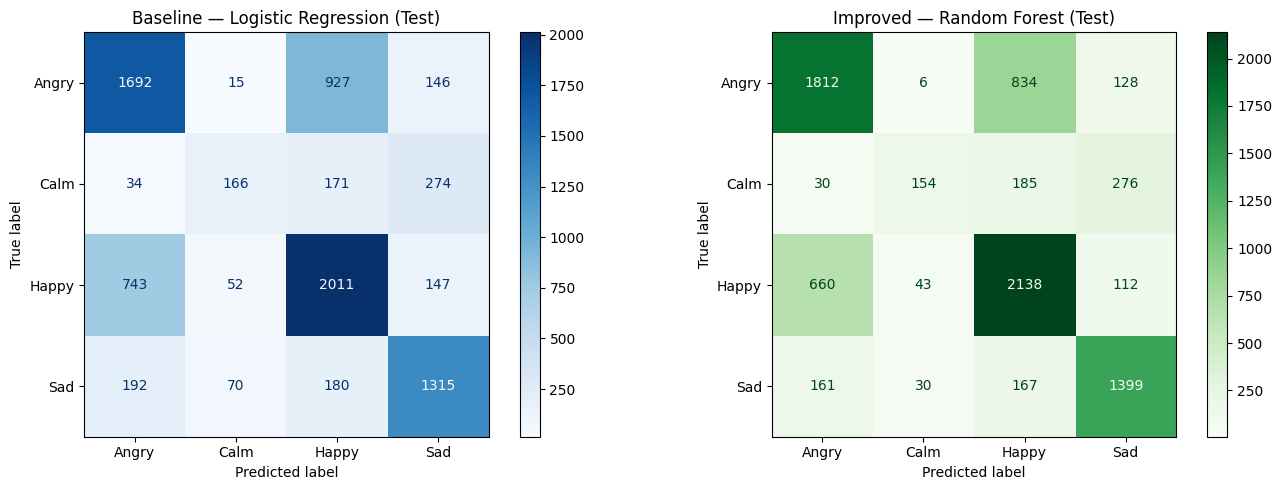

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_logreg_test),
    display_labels=log_reg.classes_
).plot(cmap='Blues', ax=axes[0])
axes[0].set_title("Baseline - Logistic Regression (Test)")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf_test),
    display_labels=rf_final.classes_
).plot(cmap='Greens', ax=axes[1])
axes[1].set_title("Improved - Decision Tree (Test)")

plt.tight_layout()
plt.show()